In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Plot appearance
# import degas as dg
# import seaborn as sns
# cmap_mako = sns.color_palette("mako", as_cmap=True)
# plt.rcParams["font.family"] = "Helvetica"

%load_ext autoreload
%autoreload 2

# In-context time delay embedding

### Simulate Lorenz 96 and measure its dimension

(np.float64(-7.297333314912736),
 np.float64(11.101528224374537),
 np.float64(-7.671683933008329),
 np.float64(11.082209011092438))

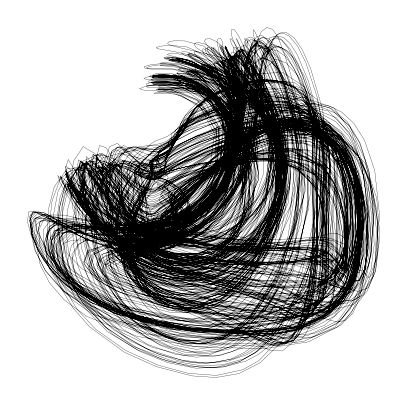

In [13]:
from scipy.integrate import solve_ivp


class Lorenz96:
    """
    Lorenz 96 model with constant forcing
    """

    def __init__(self, n=5, f=8.0):
        self.f = f
        self.n = n

    def rhs(self, t, X):

        Xdot = np.zeros_like(X)
        Xdot[2:-1] = (X[3:] - X[:-3]) * X[1:-2] - X[2:-1] + self.f
        Xdot[0] = (X[1] - X[-2]) * X[-1] - X[0] + self.f
        Xdot[1] = (X[2] - X[-1]) * X[0] - X[1] + self.f
        Xdot[-1] = (X[0] - X[-3]) * X[-2] - X[-1] + self.f

        return Xdot
    
    def __call__(self, *args, **kwargs):
        return self.rhs(*args, **kwargs)

eq = Lorenz96



nval = 10

eq = Lorenz96()
ic = eq.f * np.ones(eq.n) #+ 0.01 * np.random.normal(size=eq.n)
ic[0] += 0.01
# sol = solve_ivp(eq.rhs, [0, 30], ic, vectorized=True, max_step=0.01)
sol = solve_ivp(eq, (0, 500), ic, method="Radau")
traj = sol.y.T
traj = traj[500:] # discard transient

plt.figure(figsize=(5, 5))
plt.plot(traj[:, 0], traj[:, 1], 'k', linewidth=0.2);
plt.axis("off")



Simulate Lorenz 96 for a variety of dynamical variables and measure their dimension

In [ ]:
nvals = np.arange(5, 25)

all_traj = list()
for nval in nvals:   

    print(f"nval = {nval}", flush=True)

    eq = Lorenz96(n=nval)
    ic = eq.f * np.ones(eq.n) #+ 0.01 * np.random.normal(size=eq.n)
    ic[0] += 0.01
    # sol = solve_ivp(eq.rhs, [0, 30], ic, vectorized=True, max_step=0.01)
    sol = solve_ivp(eq, (0, 1000), ic, method="Radau")
    traj = sol.y.T
    traj = traj[500:] # discard transient

    traj.dump(f"./private_data/lorenz96_traj_{nval}.npz")
    all_traj.append(traj)

minlen = np.min([item.shape[0] for item in all_traj])
all_traj_univariate = np.array([item[:minlen, 0] for item in all_traj])


nval = 5
nval = 6
nval = 7
nval = 8
nval = 9
nval = 10
nval = 11
nval = 12
nval = 13
nval = 14
nval = 15
nval = 16
nval = 17
nval = 18
nval = 19
nval = 20
nval = 21
nval = 22
nval = 23
nval = 24


<Axes: >

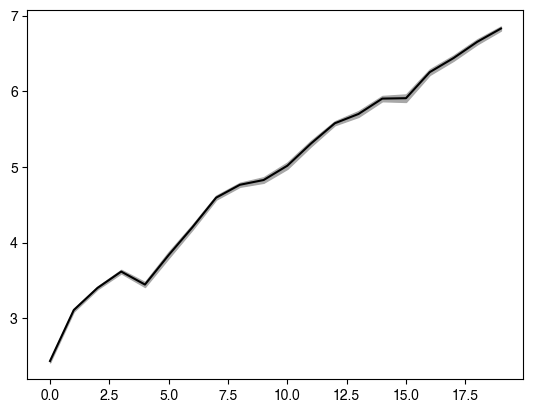

In [ ]:
from dysts.analysis import gp_dim

boostrap_size = 1000
num_bootstraps = 40

all_all_gp = list()
for i, traj in enumerate(all_traj):
    nval = nvals[i]
    print(f"i = {i}", flush=True)
    all_gp = list()
    for _ in range(num_bootstraps):
        bootstrap_inds = np.random.randint(0, len(traj), size=boostrap_size)
        all_gp.append(gp_dim(traj[bootstrap_inds]))
    all_all_gp.append(all_gp)
all_all_gp = np.array(all_all_gp)

import degas as dg
dg.plot_err(np.mean(all_all_gp, axis=1), np.std(all_all_gp, axis=1))


In [ ]:
from dysts.analysis import gp_dim, twonn_dim

all_traj = np.load("./private_cache/lorenz96_dim_alt.npz", allow_pickle=True)

all_twonn = list()
all_gp = list()
for i, traj in enumerate(all_traj):
    print(f"i = {i}", flush=True)
    all_twonn.append(twonn_dim(traj))
    all_gp.append(gp_dim(traj))
all_twonn = np.array(all_twonn)
all_gp = np.array(all_gp)


plt.plot(nvals, all_twonn, label="TwoNN")
plt.plot(nvals, all_gp, label="GP")
plt.legend()
plt.xlabel("Dynamical Variables")
plt.ylabel("Dimension")

all_twonn.dump("./private_cache/lorenz96_twonn.npz")
all_gp.dump("./private_cache/lorenz96_gp.npz")


i = 0
i = 1
i = 2
i = 3
i = 4
i = 5
i = 6
i = 7
i = 8
i = 9
i = 10
i = 11
i = 12
i = 13
i = 14
i = 15
i = 16
i = 17
i = 18
i = 19


### Load and plot the dependence of manifold dimension on the number of dynamical variables

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/var/folders/79/zct6q7kx2yl6b1ryp2rsfbtc0000gr/T/ipykernel_96828/893761511.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel(f"Manifold Dimension  $d_\mathcal{{M}}$")


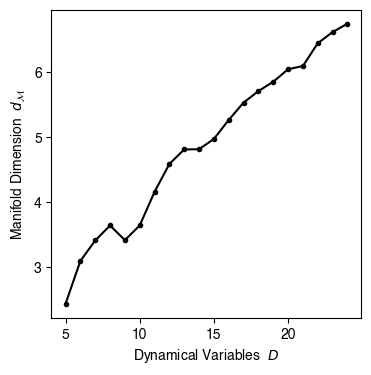

In [ ]:
nvals = np.arange(5, 25)
all_traj = np.load("./private_cache/lorenz96_dim_alt.npz", allow_pickle=True)
all_twonn = np.load("./private_cache/lorenz96_twonn.npz", allow_pickle=True)
all_gp = np.load("./private_cache/lorenz96_gp.npz", allow_pickle=True)


plt.figure(figsize=(4, 4))
# plt.plot(nvals, all_twonn, label="TwoNN", color="k")
plt.plot(nvals, all_gp, label="GP", color="k")
plt.plot(nvals, all_gp,  '.', color="k")
# plt.legend(frameon=False)
plt.xlabel("Dynamical Variables  $D$")
plt.ylabel(f"Manifold Dimension  $d_\mathcal{{M}}$")



import degas as dg
dg.better_savefig(
    f"./private_writing/fig_resources/lorenz96_dimensionality.pdf", 
    dpi=300, transparent=True, 
    # dryrun=DRYRUN,
)


### Probe how properties of the transformers change with manifold dimension

In [7]:

VOCAB_SIZE = 100
N_TRAIN = 2*40_000
N_TEST = 1000
CONTEXT_LENGTH = 32*4

from models import ChronosTokenizer
tokenizer = ChronosTokenizer(VOCAB_SIZE, -3, 3)

In [ ]:

from markov import next_token_empirical_probs_custom_comb
import torch
from analysis import js_divergence as entropy


all_gp = np.load("./private_cache/lorenz96_gp.npz", allow_pickle=True)
all_traj = np.load("./private_cache/lorenz96_dim_alt.npz", allow_pickle=True)

import glob
all_model_paths = sorted(glob.glob("./private_data/tiny_lm*"))
all_model_paths = sorted(glob.glob("./private_data/training_run/*/tiny_lm_*.pt"))
print(f"len(all_model_paths) = {len(all_model_paths)}")
from models import load_model
all_all_pr = list()
all_all_erank = list()
all_slopes = list()
all_all_gaps = list()
np.random.seed(0)
all_all_orders = list()
for ind, model_path in enumerate(all_model_paths):
    print(f"ind = {ind}", flush=True)
    print(model_path, flush=True)
    model = load_model(model_path)
    all_pr = list()
    all_erank = list()
    all_orders = list()
    all_gaps = list()
    for i, traj in enumerate(all_traj.T):
        print(f"i = {i}", flush=True)
        tok_train, aux = tokenizer.encode_series(traj, 100, 10)
        ## sample a random window of 6000 consecutive tokens
        start_ind = np.random.randint(0, len(tok_train) - 6000)
        train_tensor = torch.tensor(
            np.lib.stride_tricks.sliding_window_view(tok_train[:-1], CONTEXT_LENGTH),
            dtype=torch.long,
            #  device="cpu"
        )[start_ind:start_ind+6000]
        # logits = batched_forward(model, train_tensor, batch_size=50)
        logits = model(train_tensor)
        probs = logits.softmax(dim=-1)[:, -1, :].detach().cpu().numpy()

        ## Calculate rollout rank
        attn = model(train_tensor, collect_attn=True)[1]
        A_roll = attention_rollout(attn, add_residual=False).cpu()
        all_erank.append(erank(A_roll.mean(dim=0))[1])
        all_pr.append(participation_ratio(A_roll.mean(dim=0)))

        ## Sweep k and find best approximating Markov chain
        combs =[np.arange(CONTEXT_LENGTH - 1, CONTEXT_LENGTH - 1 -i, -1) for i in range(1, 40)]
        probs_markov, combs_markov = next_token_empirical_probs_custom_comb(
            tok_train[:-1], 
            train_tensor.detach().cpu().numpy(), 
            combs,
            L=VOCAB_SIZE+1, 
        )
        all_kl_div = []
        for item in probs_markov:
            kl_div = entropy(item + 1e-12, probs + 1e-12, axis=1)
            all_kl_div.append(kl_div)
        all_kl_div = np.array(all_kl_div)
        best_model_ind = np.argmin(all_kl_div, axis=0)
        best_comb_len = np.array([len(item) for item in combs])[best_model_ind]
        all_orders.append(np.mean(best_comb_len))


    all_all_erank.append(np.array(all_erank))
    all_all_pr.append(np.array(all_pr))
    print("erank", spearmanr(all_gp, np.array(all_erank)).correlation)
    print("pr", spearmanr(all_gp, np.array(all_pr)).correlation)
    all_all_orders.append(np.array(all_orders))
    print("model orders", spearmanr(all_gp, np.array(all_orders)).correlation)
    # print("Running Mean Slope: ", np.mean(all_slopes))
    # break
all_all_erank = np.array(all_all_erank)
all_all_orders = np.array(all_all_orders)
all_all_pr = np.array(all_all_pr)


# all_all_pr.dump("./private_cache/lorenz96_pr2.npz")
# all_all_erank.dump("./private_cache/lorenz96_erank2.npz")
# all_all_orders.dump("./private_cache/lorenz96_orders2.npz")



len(all_model_paths) = 37
ind = 0
./private_data/training_run/Arneodo_CellCycle/tiny_lm_20260123_105920_Arneodo_CellCycle.pt
i = 0
i = 1
i = 2
i = 3
i = 4
i = 5
i = 6
i = 7
i = 8
i = 9
i = 10
i = 11
i = 12
i = 13
i = 14
i = 15
i = 16
i = 17
i = 18
i = 19
erank 0.4015037593984962
pr 0.4015037593984962
model orders 0.47067669172932325
ind = 1
./private_data/training_run/ArnoldBeltramiChildress_HyperWang/tiny_lm_20260126_051605_ArnoldBeltramiChildress_HyperWang.pt
i = 0
i = 1
i = 2
i = 3
i = 4
i = 5
i = 6
i = 7
i = 8
i = 9
i = 10
i = 11
i = 12
i = 13
i = 14
i = 15
i = 16
i = 17
i = 18
i = 19
erank -0.26917293233082706
pr -0.26917293233082706
model orders 0.4541353383458646
ind = 2
./private_data/training_run/BelousovZhabotinsky_SprottR/tiny_lm_20260123_081720_BelousovZhabotinsky_SprottR.pt
i = 0
i = 1
i = 2
i = 3
i = 4
i = 5
i = 6
i = 7
i = 8
i = 9
i = 10
i = 11
i = 12
i = 13
i = 14
i = 15
i = 16
i = 17
i = 18
i = 19
erank 0.4090225563909774
pr 0.4090225563909774
model orders -0.460150375